In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [77]:
!cat ../data/height-weight-02.csv

## Approximation

In [78]:
# Load the dataset from a CSV file
# df = pd.read_csv('../data/height-weight-01.csv')
df = pd.read_csv('../data/height-weight-02.csv')

# Extract the height and weight data
height = df['Height'].values
weight = df['Weight'].values

In [79]:
height

array([160, 165, 170, 175, 180, 185, 190, 195, 197, 200, 205, 207, 210,
       212, 215])

In [80]:
weight

array([55, 60, 65, 70, 75, 80, 85, 90, 94, 75, 88, 99, 80, 82, 83])

In [81]:
# Perform linear approximation using numpy's polyfit
# Degree of 1 for a linear model
slope, intercept = np.polyfit(height, weight, 1)

# Print the intercept and slope
print(f"Intercept: {intercept}")
print(f"Slope: {slope}")

Intercept: -25.49784508559789
Slope: 0.5455225667424876


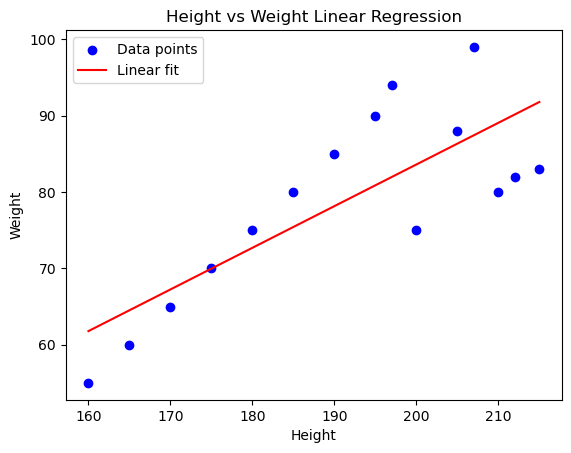

In [82]:
# Plot the data points
plt.scatter(height, weight, color='blue', label='Data points')

# Plot the regression line
plt.plot(height, slope * height + intercept, color='red', label='Linear fit')

# Add labels and title
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight Linear Regression')

# Add legend
plt.legend()

# Show the plot
plt.show()

## with data split

Intercept: -72.17572865178113
Slope: 0.8094426453042444


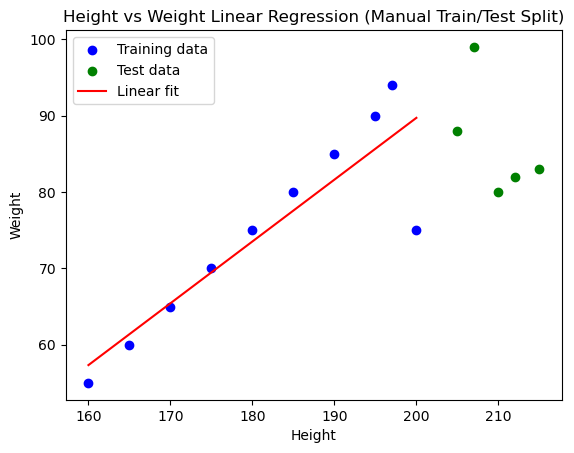

In [83]:
# Extract the height and weight data
height = df['Height'].values
weight = df['Weight'].values

height_train = height[:10]
weight_train = weight[:10]

height_test = height[10:]
weight_test = weight[10:]

# Perform linear regression using numpy's polyfit on the training set
slope, intercept = np.polyfit(height_train, weight_train, 1)

# Print the intercept and slope
print(f"Intercept: {intercept}")
print(f"Slope: {slope}")

# Plot the training data points
plt.scatter(height_train, weight_train, color='blue', label='Training data')

# Plot the test data points
plt.scatter(height_test, weight_test, color='green', label='Test data')

# Plot the regression line (based on the training set)
plt.plot(height_train, slope * height_train + intercept, color='red', label='Linear fit')

# Add labels and title
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight Linear Regression (Manual Train/Test Split)')

# Add legend
plt.legend()

# Show the plot
plt.show()

## Model

In [84]:
# Calculate and print the predictions for the test set
weight_pred = slope * height_test + intercept

## Error calculations

In [85]:
# Calculate error metrics
mae = np.mean(np.abs(weight_test - weight_pred))  # Mean Absolute Error
mse = np.mean((weight_test - weight_pred) ** 2)   # Mean Squared Error
rmse = np.sqrt(mse)                              # Root Mean Squared Error

# Print the error metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Optional: Print test set predictions vs actual values
print("\nTest Set Predictions vs Actual Values:")
for actual, predicted in zip(weight_test, weight_pred):
    print(f"Actual: {actual}, Predicted: {predicted}")

Mean Absolute Error (MAE): 12.693778762570355
Mean Squared Error (MSE): 204.50935088048874
Root Mean Squared Error (RMSE): 14.300676588206892

Test Set Predictions vs Actual Values:
Actual: 88, Predicted: 93.76001363558896
Actual: 99, Predicted: 95.37889892619745
Actual: 80, Predicted: 97.80722686211018
Actual: 82, Predicted: 99.42611215271867
Actual: 83, Predicted: 101.8544400886314


# Interpolation

Mean Absolute Error (MAE): 73.46666666666667
Mean Squared Error (MSE): 5766.4
Root Mean Squared Error (RMSE): 75.93681584053942


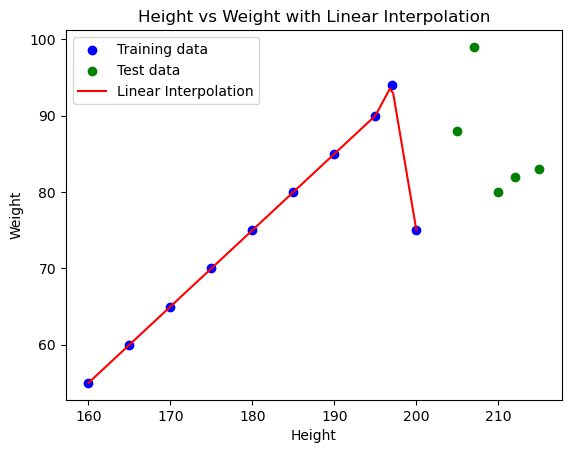


Test Set Predictions vs Actual Values:
Actual: 88, Predicted: 43.333333333333336
Actual: 99, Predicted: 30.66666666666667
Actual: 80, Predicted: 11.666666666666671
Actual: 82, Predicted: -1.0
Actual: 83, Predicted: -20.0


In [86]:
# Create a linear interpolation function based on the training data
linear_interpolation = interp1d(height_train, weight_train, kind='linear', fill_value='extrapolate')

# Perform interpolation on the test set
weight_pred_test = linear_interpolation(height_test)

# Calculate error metrics for the test set
mae = np.mean(np.abs(weight_test - weight_pred_test))  # Mean Absolute Error
mse = np.mean((weight_test - weight_pred_test) ** 2)   # Mean Squared Error
rmse = np.sqrt(mse)                                   # Root Mean Squared Error

# Print the error metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Plot the training data points
plt.scatter(height_train, weight_train, color='blue', label='Training data')

# Plot the test data points
plt.scatter(height_test, weight_test, color='green', label='Test data')

# Define new heights for smooth interpolation plot (optional)
new_heights = np.linspace(min(height_train), max(height_train), num=100)

# Plot the interpolation line for the training set
interpolated_weights = linear_interpolation(new_heights)
plt.plot(new_heights, interpolated_weights, color='red', label='Linear Interpolation')

# Add labels and title
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight with Linear Interpolation')

# Add legend
plt.legend()

# Show the plot
plt.show()

# Optional: Print test set predictions vs actual values
print("\nTest Set Predictions vs Actual Values:")
for actual, predicted in zip(weight_test, weight_pred_test):
    print(f"Actual: {actual}, Predicted: {predicted}")

## Polynomial approximation

4
[ 1.00000000e+00 -1.70558281e-15 -3.18541616e-14  3.89323295e-14]


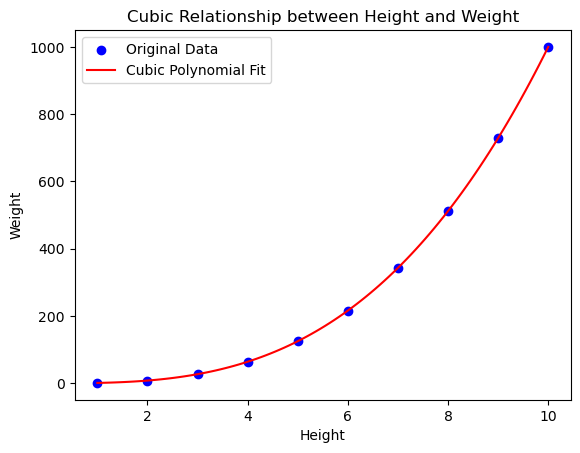

Cubic Polynomial Coefficients: [ 1.00000000e+00 -1.70558281e-15 -3.18541616e-14  3.89323295e-14]


In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample dataset with a cubic relationship
# y = ax^3 + bx^2 + cx + d (e.g., a=1, b=0, c=0, d=0)
height = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
weight = height**3  # Cubic relationship

# Fit a cubic polynomial
coefficients = np.polyfit(height, weight, 3)
print(len(coefficients))
print(coefficients)

polynomial_model = np.poly1d(coefficients)

# Generate points for plotting the polynomial curve
new_heights = np.linspace(min(height), max(height), num=100)

predicted_weights = polynomial_model(new_heights)

# Plot the original data points and the fitted polynomial curve
plt.scatter(height, weight, color='blue', label='Original Data')
plt.plot(new_heights, predicted_weights, color='red', label='Cubic Polynomial Fit')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Cubic Relationship between Height and Weight')
plt.legend()
plt.show()

# Print the coefficients of the cubic polynomial
print("Cubic Polynomial Coefficients:", coefficients)